# From Hamiltonian simulation to experimental decision support

This notebook shows the broader potential of the package and then uses **real STM data and trained models** from `Inhomogeneous-Heisenberg-HL`. The goal is not merely to output couplings: it is to make assumptions, uncertainty, local consistency, and exportable evidence visible to an experimentalist.

> Unit convention: in this project, `1 DMRGPy energy unit = 10 meV`. The legacy numerical range `3.0–4.5` therefore corresponds to `30–45 meV`. The interface below applies this conversion and reports physical meV. A production artifact should store this convention in its manifest.

## What the small package already connects

| Layer | Current capability | Why it matters |
|---|---|---|
| Physics | Bond-inhomogeneous and homogeneous $J_1$-$J_2$-… Heisenberg families | Parameters have an explicit physical meaning |
| Simulation | Backend-independent protocol plus real DMRGPy | Synthetic training data are reproducible |
| Data | Portable NPZ with spectra, targets, bias grid, seed, and metadata | Training sets remain auditable |
| Learning views | Local three-site bonds or global full-chain targets | Representation matches the Hamiltonian structure |
| Models | Ridge, random forest, MLP, and 1D CNN | Baselines and nonlinear models share one interface |
| Training safety | Grouped splits and target scaling | Prevents window leakage and unit mistakes |
| Experiment | CSV loading, preprocessing, ensemble inference, QC, export | Experimentalists get a short, inspectable workflow |
| Validation | Ensemble spread, overlapping-window disagreement, range checks | Results include reasons to trust or review them |

In [1]:
from pathlib import Path
import json
import sys
import tempfile

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from hamlet.experimental import ExperimentalChainAnalyzer
from hamlet.io import load_spectroscopy_csv
from hamlet.models import available_supervised_models
from hamlet.preprocessing import SpectralPreprocessor
from hamlet.training import TrainingPreprocessingConfig
from hamlet.systems import (
    HomogeneousHeisenbergFamily, InhomogeneousHeisenbergFamily,
)

REFERENCE = ROOT / 'reference' / 'Inhomogeneous-Heisenberg-HL'
EXPERIMENT = REFERENCE / 'data' / 'experimental' / 'ChainIH_L6_SYM.csv'
MODEL_PATHS = [
    REFERENCE / 'models' / 'trained_models' / f'enhanced_seed_{seed}' / 'model.keras'
    for seed in (43, 44, 45)
]
assert EXPERIMENT.exists() and all(path.exists() for path in MODEL_PATHS)
print('Models available to new studies:', available_supervised_models())
print('Real experiment:', EXPERIMENT.name)

Models available to new studies: ('keras_mlp', 'keras_cnn', 'ridge', 'random_forest')
Real experiment: ChainIH_L6_SYM.csv


## The same API describes different scientific questions

These configurations can be passed to `generate_dataset(...)` with DMRGPy. The first learns every bond locally; the second learns global interaction ranges. No simulator is launched in this cell—the point is that the scientific parameterization is explicit.

In [2]:
bond_resolved_problem = InhomogeneousHeisenbergFamily(
    n_sites=12, coupling_range_mev=(30.0, 45.0)
)
global_j1_j2_j3_problem = HomogeneousHeisenbergFamily(
    n_sites=12,
    coupling_ranges_mev=((30.0, 45.0), (0.0, 10.0), (-2.0, 2.0)),
)
print('Bond-resolved targets:', bond_resolved_problem.parameter_names)
print('Global targets:', global_j1_j2_j3_problem.parameter_names)

Bond-resolved targets: ('J_bond_0', 'J_bond_1', 'J_bond_2', 'J_bond_3', 'J_bond_4', 'J_bond_5', 'J_bond_6', 'J_bond_7', 'J_bond_8', 'J_bond_9', 'J_bond_10')
Global targets: ('J1', 'J2', 'J3')


## Inspect the real experimental input before inference

The loader validates the required long-form schema and confirms that all sites share the same bias grid. Experimental data are never hidden inside a model-specific tensor.

In [3]:
frame = pd.read_csv(EXPERIMENT)
raw_bias, raw_map = load_spectroscopy_csv(EXPERIMENT)
display(frame.head())
print('Rows:', len(frame), '| sites:', raw_map.shape[0], '| bias points/site:', raw_map.shape[1])
print('Bias coverage [meV]:', (raw_bias.min(), raw_bias.max()))
assert set(frame.columns) >= {'site', 'bias_meV', 'didv_A'}
assert np.isfinite(raw_map).all()

,site,bias_meV,didv_A
0,1,0.000000,0.376950
1,1,0.502513,0.376957
2,1,1.005025,0.376300
3,1,1.507538,0.375803
4,1,2.010050,0.377685


Rows: 1200 | sites: 6 | bias points/site: 200
Bias coverage [meV]: (0.0, 100.0)


## The experimentalist-facing interface

After choosing a reviewed model ensemble and its preprocessing manifest, the actual analysis is one call. The interface performs loading → preprocessing → sliding windows → ensemble inference → overlap reconstruction → diagnostics.

In [4]:
cutoff_config = TrainingPreprocessingConfig(
    bias_cutoff_mev=50.0,  # selected from the usable experimental spectrum
    output_points=200,
    baseline_range_mev=(0.0, 3.0),
    scale_range_mev=(40.0, 50.0),
)
preprocessor = cutoff_config.build_preprocessor()
analyzer = ExperimentalChainAnalyzer.from_keras_paths(
    MODEL_PATHS,
    preprocessor,
    output_range=(30.0, 45.0),
    coupling_unit='meV',
)
result = analyzer.analyze_csv(EXPERIMENT)
print('Analysis status:', result.diagnostics.status.upper())
print('Ensemble size:', result.diagnostics.ensemble_size)
print('Sites / reconstructed bonds:', result.n_sites, '/', result.n_bonds)

2026-08-18 15:55:47.008815: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-18 15:55:47.009589: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-18 15:55:47.135426: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-18 15:55:50.429994: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Analysis status: OK
Ensemble size: 3
Sites / reconstructed bonds: 6 / 5


## Inspect numerical results and diagnostics

Uncertainty below is the standard deviation across three independently trained models. It is useful evidence of model instability, but it is not yet a complete physical confidence interval.

In [5]:
coupling_table = pd.DataFrame({
    'bond': np.arange(result.n_bonds),
    'left_site': np.arange(result.n_bonds),
    'right_site': np.arange(1, result.n_sites),
    'coupling': result.coupling_mean,
    'ensemble_std': result.coupling_std,
    'unit': result.coupling_unit,
})
display(coupling_table.style.format({'coupling': '{:.4f}', 'ensemble_std': '{:.4f}'}))
display(pd.Series({
    'status': result.diagnostics.status,
    'mean overlapping-window disagreement': result.diagnostics.mean_overlap_disagreement,
    'maximum ensemble standard deviation': result.diagnostics.max_ensemble_std,
    'predictions outside training range': result.diagnostics.fraction_predictions_outside_training_range,
    'warnings': result.diagnostics.warnings,
}, name='quality control'))

,bond,left_site,right_site,coupling,ensemble_std,unit
0,0,0,1,36.9443,0.0786,meV
1,1,1,2,33.7212,0.1998,meV
2,2,2,3,35.7256,0.0665,meV
3,3,3,4,34.0769,0.0797,meV
4,4,4,5,36.2696,0.2083,meV


status                                        ok
mean overlapping-window disagreement    1.320974
maximum ensemble standard deviation     0.208334
predictions outside training range           0.0
warnings                                      ()
Name: quality control, dtype: object

## One-figure quality-control dashboard

The dashboard keeps the raw data, exact model input, inferred Hamiltonian, ensemble spread, and overlapping-window consistency in the same report. This lets an experimentalist catch preprocessing mistakes or locally unstable predictions visually.

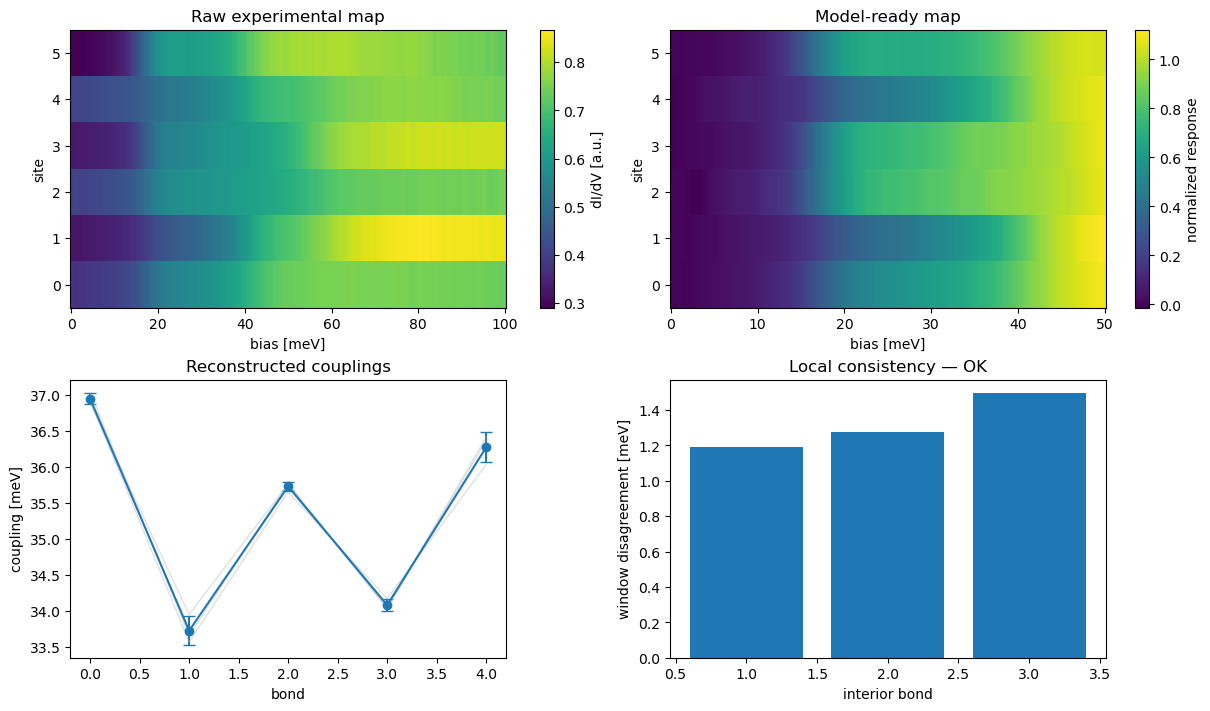

In [6]:
figure = result.plot_summary()
plt.show()

## Audit the model ensemble

The original training metrics are read next to the experimental result. A production package will save these together with coupling units, target scaling, preprocessing, training-data identity, and code version in one artifact manifest.

In [7]:
model_audit = []
for path in MODEL_PATHS:
    metrics = json.loads((path.parent / 'metrics.json').read_text())
    model_audit.append({
        'artifact': path.parent.name,
        'seed': metrics['seed'],
        'validation_loss': metrics['val_loss'],
        'test_fidelity': metrics['fidelity_total'],
        'epochs': metrics['epochs_completed'],
    })
display(pd.DataFrame(model_audit))

,artifact,seed,validation_loss,test_fidelity,epochs
0,enhanced_seed_43,43,0.001853,0.894450,100
1,enhanced_seed_44,44,0.001871,0.887921,100
2,enhanced_seed_45,45,0.001856,0.892013,100


## Stress-test the result against measurement perturbations

A useful interface should help users challenge a result. Here we add controlled Gaussian perturbations to the real raw map and measure the mean absolute change in reconstructed couplings. This is a sensitivity test, not a replacement for a laboratory noise model.

,noise / raw signal range,mean coupling shift,shift std
0,0.000,0.000000,0.000000
1,0.002,0.051545,0.013834
2,0.005,0.131226,0.030493
3,0.010,0.239987,0.066361
4,0.020,0.619447,0.102432


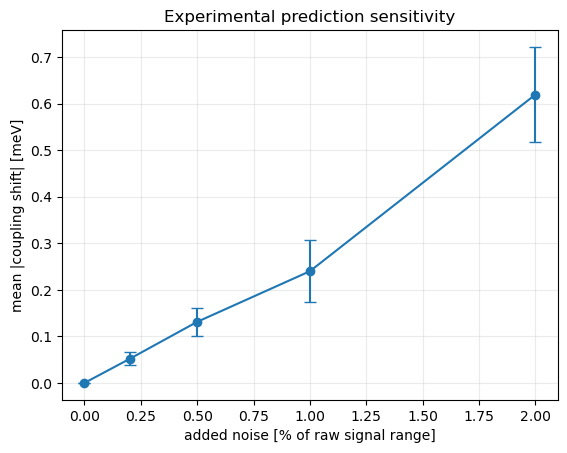

In [8]:
rng = np.random.default_rng(123)
signal_scale = np.ptp(result.raw_spectra)
noise_fractions = np.array([0.0, 0.002, 0.005, 0.01, 0.02])
repetitions = 6
sensitivity_mean, sensitivity_std = [], []
for fraction in noise_fractions:
    shifts = []
    for _ in range(repetitions):
        perturbed = result.raw_spectra + rng.normal(
            scale=fraction * signal_scale, size=result.raw_spectra.shape
        )
        perturbed_result = analyzer.analyze(perturbed, result.raw_bias_mev, source='noise test')
        shifts.append(np.mean(np.abs(perturbed_result.coupling_mean - result.coupling_mean)))
    sensitivity_mean.append(np.mean(shifts))
    sensitivity_std.append(np.std(shifts))

sensitivity = pd.DataFrame({
    'noise / raw signal range': noise_fractions,
    'mean coupling shift': sensitivity_mean,
    'shift std': sensitivity_std,
})
display(sensitivity)
plt.errorbar(noise_fractions * 100, sensitivity_mean, yerr=sensitivity_std, fmt='o-', capsize=4)
plt.xlabel('added noise [% of raw signal range]')
plt.ylabel(f'mean |coupling shift| [{result.coupling_unit}]')
plt.title('Experimental prediction sensitivity')
plt.grid(alpha=0.25)
plt.show()

## Export results for a lab record or collaborator

The same result object writes a machine-readable coupling table and a JSON report containing diagnostics. The QC figure can be saved as PNG or PDF.

['bond,left_site,right_site,coupling,uncertainty,unit', '0,0,1,36.944305419921875,0.0785968005657196,meV', '1,1,2,33.721248626708984,0.19982169568538666,meV', '2,2,3,35.72555923461914,0.06651952117681503,meV']
Report fields: ['coupling_mean', 'coupling_std', 'coupling_unit', 'diagnostics', 'n_bonds', 'n_sites', 'source']
Files: ['couplings.csv', 'report.json', 'summary.png']


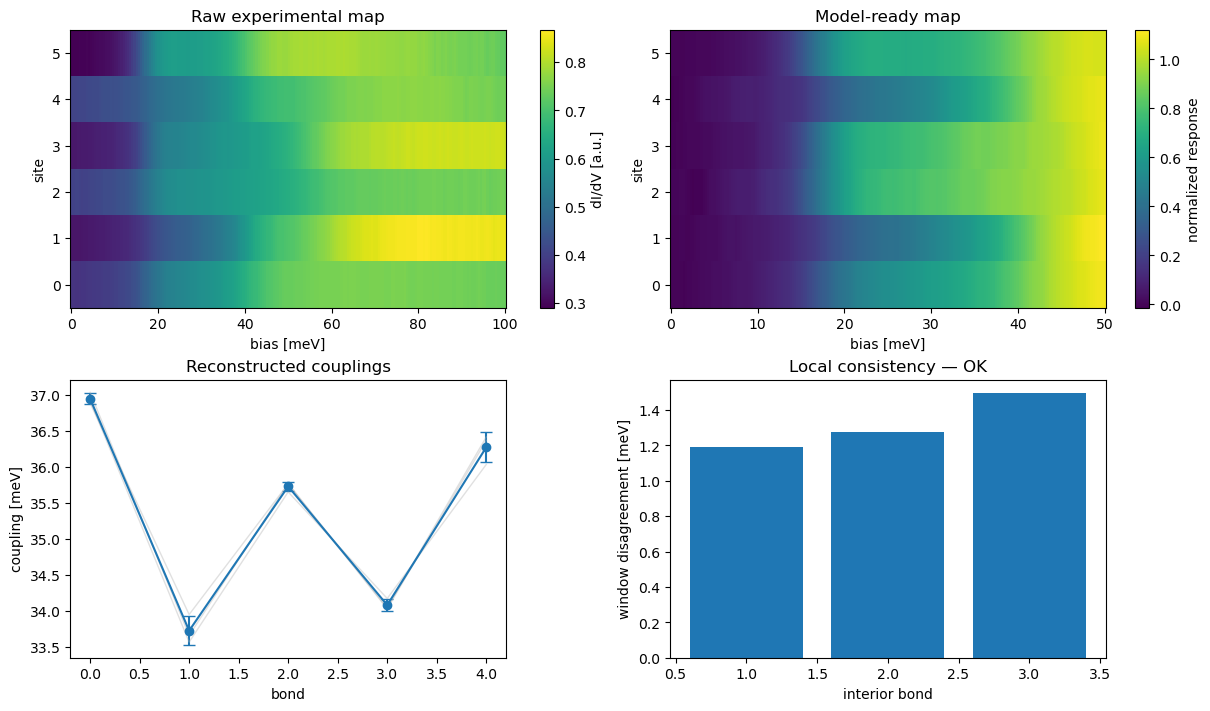

In [9]:
with tempfile.TemporaryDirectory() as directory:
    output = Path(directory)
    result.save_couplings_csv(output / 'couplings.csv')
    result.save_report_json(output / 'report.json')
    result.plot_summary().savefig(output / 'summary.png', dpi=120)
    print((output / 'couplings.csv').read_text().splitlines()[:4])
    report_preview = json.loads((output / 'report.json').read_text())
    print('Report fields:', sorted(report_preview))
    print('Files:', sorted(path.name for path in output.iterdir()))

## The same workflow without Python

After installation, an experimentalist can run:

```bash
hamlet-analyze ChainIH_L6_SYM.csv \
  --models enhanced_seed_43/model.keras enhanced_seed_44/model.keras enhanced_seed_45/model.keras \
  --output-range 30.0 45.0 \
  --unit meV \
  --output-dir ChainIH_L6_analysis
```

This creates `couplings.csv`, `report.json`, and `summary.png` and prints an `ok` or `review` status.

## What this can and cannot check

Already automatic:

- input schema, finite values, site count, and common bias grid;
- exact preprocessing shown beside raw measurements;
- ensemble variation and local-window consistency;
- excursions outside the target range used for training;
- sensitivity to controlled measurement perturbations;
- traceable numerical and visual exports.

Still required before claiming calibrated physics:

- a versioned model manifest recording `1 DMRGPy energy unit = 10 meV`;
- experimental noise and systematic-error calibration;
- out-of-distribution checks against stored training-feature statistics;
- forward simulation of the inferred Hamiltonian and comparison with the measured spectrum;
- validation on known reference samples and, ideally, independent inference methods.

The interface is therefore designed as decision support with visible diagnostics—not as a black-box certificate.